In [ ]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sentence_transformers import SentenceTransformer
from transformers import AutoModel, AutoTokenizer
from peft import LoraConfig, get_peft_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

import random
torch.manual_seed(7)
np.random.seed(7)
random.seed(7)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


file_path = 'Java1.csv'
data = pd.read_csv(file_path)


data['concatenated_text'] = data['Processed Body'] + " " + data['Tags'] + " " + data['Title']


label_mapping = {'Basic': 0, 'Intermediate': 1, 'Advanced': 2}
data['encoded_labels'] = data['Label'].map(label_mapping)
labels = data['encoded_labels'].values

numerical_cols = [
    'User_Reputation', 'Bronze_badge', 'Gold_badge', 'Silver_badge',
    'User Id', 'Accepted Answer ID', 'View Count', 'Answer Count',
    'Score', 'Interval from first', 'Interval from accepted',
    'Total count urls and imgs', 'LOC', 'Question_Length'
]


combined_texts = data['concatenated_text'].tolist()
numerical_data = data[numerical_cols].values
labels = data['Label'].map(label_mapping).values  

X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    combined_texts, numerical_data, labels,
    test_size=0.20, random_state=42, stratify=labels
)

imputer = SimpleImputer(strategy='mean')
X_num_train = imputer.fit_transform(X_num_train)
X_num_test = imputer.transform(X_num_test)

scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)
X_num_test = scaler.transform(X_num_test)


model_name = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
base_model = AutoModel.from_pretrained(model_name)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)
model = get_peft_model(base_model, lora_config)
model.to(device)

class StackOverflowDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        inputs = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            return_tensors="pt",
            max_length=512
        )
        if "token_type_ids" in inputs:
            del inputs["token_type_ids"]
        return {
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = StackOverflowDataset(X_text_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

class SBERTWithClassification(nn.Module):
    def __init__(self, base_model, num_classes):
        super(SBERTWithClassification, self).__init__()
        self.base_model = base_model
        self.classifier = nn.Linear(384, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_embedding)
        return logits

num_classes = len(label_mapping)
classifier_model = SBERTWithClassification(model, num_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(classifier_model.parameters(), lr=5e-5)

num_epochs = 3
for epoch in range(num_epochs):
    classifier_model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        outputs = classifier_model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader):.4f}")

def extract_embeddings(texts):
    inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt", max_length=512).to(device)
    if "token_type_ids" in inputs:
        del inputs["token_type_ids"]
    with torch.no_grad():
        outputs = classifier_model.base_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu().numpy()

train_embeddings = np.array([extract_embeddings([text])[0] for text in X_text_train])
test_embeddings = np.array([extract_embeddings([text])[0] for text in X_text_test])

X_train_combined = np.hstack((train_embeddings, X_num_train))
X_test_combined = np.hstack((test_embeddings, X_num_test))

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_combined, y_train)

clf = RandomForestClassifier(
    n_estimators=400, max_depth=20, bootstrap=True,
    max_features='sqrt', min_samples_split=10,
    min_samples_leaf=1, random_state=42
)
clf.fit(X_train_resampled, y_train_resampled)

y_pred = clf.predict(X_test_combined)
print(classification_report(y_test, y_pred, target_names=label_mapping.keys(), digits=4))


In [2]:
importances = clf.feature_importances_


In [3]:
embedding_feature_names = [f"emb_{i}" for i in range(train_embeddings.shape[1])]
all_feature_names = embedding_feature_names + numerical_cols


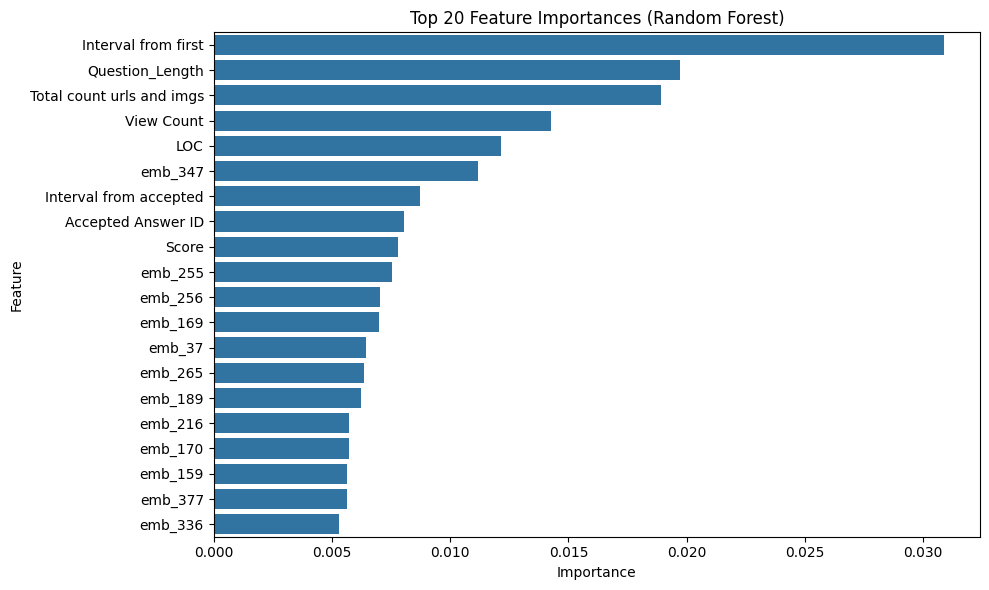

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
})

top_n = 20
top_features = feature_importance_df.sort_values(by="Importance", ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=top_features)
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()
